## Plot MUSICAv0 vs UKAQR scatter plot
- This script is used to visualize MUSICAv0 vs UKAQR seasonal PM2.5 scatter plot

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import glob
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from zhiyi.plot.cbar import Cbar


In [ ]:
# Winter


# var_name = "O3"
var_name = "PM25"

# MUSICA fv0.1
data_dir_musica = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01"
files_musica = (
    sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc"))
    + sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc"))
)

# MetOffice
# O3
# met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg"

# PM25
met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg"

gdf = gpd.read_file(met_gpkg)
gdf["stdTime"] = pd.to_datetime(gdf["stdTime"])

# start = pd.Timestamp("2017-12-01", tz="UTC")
# end   = pd.Timestamp("2018-12-01", tz="UTC")

# # djf. e a
start = pd.Timestamp("2017-12-01", tz="UTC")
end   = pd.Timestamp("2018-03-01", tz="UTC")

# # mam. f b
# start = pd.Timestamp("2017-03-01", tz="UTC")
# end   = pd.Timestamp("2018-06-01", tz="UTC")

# # # jja. g c
# start = pd.Timestamp("2017-06-01", tz="UTC")
# end   = pd.Timestamp("2018-09-01", tz="UTC")

# son. h d
# start = pd.Timestamp("2017-09-01", tz="UTC")
# end   = pd.Timestamp("2018-12-01", tz="UTC")

mask_time = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask_time].copy()

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)
gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds  # minx,miny,maxx,maxy
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()
pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lon_centers = pivot.columns.values.astype(float)
lat_centers = pivot.index.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))
lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)


factor_met = 1.0
data2d_met = pivot.values
data2d_met_ppbv = data2d_met * factor_met

ne_admin1 = gpd.read_file(
    "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
)

if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL", "IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]
uk_ie_union = ne_uk_ie.union_all()

points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)
inside = points.within(uk_ie_union).values
mask_land = inside.reshape(data2d_met_ppbv.shape)

data2d_met_masked = np.where(mask_land, data2d_met_ppbv, np.nan)


ds_mus = xr.open_mfdataset(files_musica, combine="by_coords")

lons_raw = ds_mus["lon"]
lons_deg = xr.where(lons_raw > 180, lons_raw - 360, lons_raw)
ds_mus = ds_mus.assign_coords(lon=lons_deg)
ds_mus = ds_mus.sortby("lon")
factor_mus = 1e9
var3d = ds_mus[var_name] * factor_mus
var_sfc = var3d.isel(lev=-1)   
var_mean = var_sfc.mean(dim="time")

var_on_met = var_mean.interp(
    lat=lat_centers,
    lon=lon_centers
)

data2d_mus = var_on_met.values
data2d_mus_masked = np.where(mask_land, data2d_mus, np.nan)

diff = data2d_mus_masked - data2d_met_masked
absmax = np.nanmax(np.abs(diff))

cbar_obj = Cbar("myct_cont")
cmap_main = cbar_obj.cmap
cmap_diff = plt.get_cmap("RdBu_r")


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


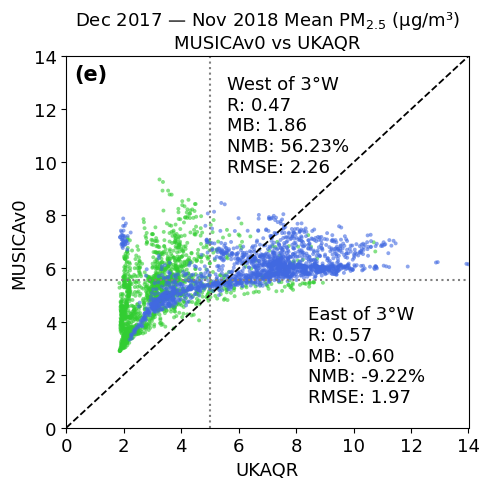

In [ ]:
# MUSICA vs UKAQR

x = data2d_met_masked.ravel()  
y = data2d_mus_masked.ravel()

mask_valid = (~np.isnan(x)) & (~np.isnan(y))
xv = x[mask_valid]
yv = y[mask_valid]

lonv = lonc2d.ravel()[mask_valid]

threshold = -3.0
mask_west = lonv < threshold     # West of 3°W
mask_east = lonv >= threshold    # East of 3°W

# PM25
xmin = 0
xmax = max(xv.max(), yv.max())   # PM2.5

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

# PM25
ax.scatter(
    xv[mask_west], yv[mask_west],
    s=8, alpha=0.6, edgecolor="none",
    color="limegreen",
    label="West of 3°W"
)

ax.scatter(
    xv[mask_east], yv[mask_east],
    s=8, alpha=0.6, edgecolor="none",
    color="royalblue",
    label="East of 3°W"
)

ax.set_xlim([xmin, xmax])
ax.set_ylim([xmin, xmax])

# PM25
ax.set_xticks(np.arange(xmin, xmax + 1, 2))
ax.set_yticks(np.arange(xmin, xmax + 1, 2))

xx = np.linspace(xmin, xmax, 200)
ax.plot(xx, xx, ls="--", lw=1.3, color="black", label="1:1")

mean_x = np.mean(xv)
mean_y = np.mean(yv)

ax.axvline(mean_x, ls=":", lw=1.5, color="grey")
ax.axhline(mean_y, ls=":", lw=1.5, color="grey")

ax.tick_params(axis="both", labelsize=13)
ax.set_xlabel("UKAQR", fontsize=13)
ax.set_ylabel("MUSICAv0", fontsize=13)

ax.set_title(
    "Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³)\nMUSICAv0 vs UKAQR",
    fontsize=13
)

def calc_stats(x_sub, y_sub):
    mb = np.mean(y_sub - x_sub)
    rmse = np.sqrt(np.mean((y_sub - x_sub) ** 2))
    corr = np.corrcoef(x_sub, y_sub)[0, 1] if len(x_sub) > 1 else np.nan
    nmb = np.sum(y_sub - x_sub) / np.sum(x_sub) * 100.0
    return corr, mb, nmb, rmse

# West / East
x_w, y_w = xv[mask_west], yv[mask_west]
x_e, y_e = xv[mask_east], yv[mask_east]

corr_w, mb_w, nmb_w, rmse_w = calc_stats(x_w, y_w)
corr_e, mb_e, nmb_e, rmse_e = calc_stats(x_e, y_e)

text_w = (
    "West of 3°W\n"
    f"R: {corr_w:.2f}\n"
    f"MB: {mb_w:.2f}\n"
    f"NMB: {nmb_w:.2f}%\n"
    f"RMSE: {rmse_w:.2f}"
)

text_e = (
    "East of 3°W\n"
    f"R: {corr_e:.2f}\n"
    f"MB: {mb_e:.2f}\n"
    f"NMB: {nmb_e:.2f}%\n"
    f"RMSE: {rmse_e:.2f}"
)

ax.text(
    0.4, 0.95, text_w,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

ax.text(
    0.60, 0.33, text_e,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

corr_all, mb_all, nmb_all, rmse_all = calc_stats(xv, yv)

# PM25
text_all = (
    "All UK\n"
    f"R: {corr_all:.2f}\n"
    f"MB: {mb_all:.2f}\n"
    f"NMB: {nmb_all:.2f}%\n"
    f"RMSE: {rmse_all:.2f}"
)

# ax.text(
#     0.43, 0.98, text_all,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     fontsize=13,
#     color="k"
# )

ax.text(
    0.02, 0.98, "(e)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15, fontweight="bold"
)

plt.tight_layout()


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


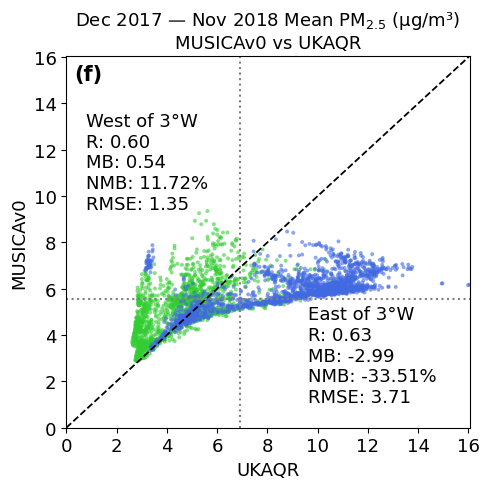

In [ ]:
# Spring


# var_name = "O3"
var_name = "PM25"

# MUSICA fv0.1
data_dir_musica = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01"
files_musica = (
    sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc"))
    + sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc"))
)

# MetOffice
# O3
# met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg"

# PM25
met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg"

gdf = gpd.read_file(met_gpkg)
gdf["stdTime"] = pd.to_datetime(gdf["stdTime"])

# start = pd.Timestamp("2017-12-01", tz="UTC")
# end   = pd.Timestamp("2018-12-01", tz="UTC")

# # djf. e a
# start = pd.Timestamp("2017-12-01", tz="UTC")
# end   = pd.Timestamp("2018-03-01", tz="UTC")

# # mam. f b
start = pd.Timestamp("2017-03-01", tz="UTC")
end   = pd.Timestamp("2018-06-01", tz="UTC")

# # # jja. g c
# start = pd.Timestamp("2017-06-01", tz="UTC")
# end   = pd.Timestamp("2018-09-01", tz="UTC")

# son. h d
# start = pd.Timestamp("2017-09-01", tz="UTC")
# end   = pd.Timestamp("2018-12-01", tz="UTC")

mask_time = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask_time].copy()

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)
gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds  # minx,miny,maxx,maxy
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()
pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lon_centers = pivot.columns.values.astype(float)
lat_centers = pivot.index.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))
lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)


factor_met = 1.0
data2d_met = pivot.values
data2d_met_ppbv = data2d_met * factor_met

ne_admin1 = gpd.read_file(
    "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
)

if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL", "IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]
uk_ie_union = ne_uk_ie.union_all()

points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)
inside = points.within(uk_ie_union).values
mask_land = inside.reshape(data2d_met_ppbv.shape)

data2d_met_masked = np.where(mask_land, data2d_met_ppbv, np.nan)


ds_mus = xr.open_mfdataset(files_musica, combine="by_coords")

lons_raw = ds_mus["lon"]
lons_deg = xr.where(lons_raw > 180, lons_raw - 360, lons_raw)
ds_mus = ds_mus.assign_coords(lon=lons_deg)
ds_mus = ds_mus.sortby("lon")
factor_mus = 1e9
var3d = ds_mus[var_name] * factor_mus
var_sfc = var3d.isel(lev=-1)   
var_mean = var_sfc.mean(dim="time")

var_on_met = var_mean.interp(
    lat=lat_centers,
    lon=lon_centers
)

data2d_mus = var_on_met.values
data2d_mus_masked = np.where(mask_land, data2d_mus, np.nan)

diff = data2d_mus_masked - data2d_met_masked
absmax = np.nanmax(np.abs(diff))

cbar_obj = Cbar("myct_cont")
cmap_main = cbar_obj.cmap
cmap_diff = plt.get_cmap("RdBu_r")

# MUSICA vs UKAQR

x = data2d_met_masked.ravel()  
y = data2d_mus_masked.ravel()

mask_valid = (~np.isnan(x)) & (~np.isnan(y))
xv = x[mask_valid]
yv = y[mask_valid]

lonv = lonc2d.ravel()[mask_valid]

threshold = -3.0
mask_west = lonv < threshold     # West of 3°W
mask_east = lonv >= threshold    # East of 3°W

# PM25
xmin = 0
xmax = max(xv.max(), yv.max())   # PM2.5

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

# PM25
ax.scatter(
    xv[mask_west], yv[mask_west],
    s=8, alpha=0.6, edgecolor="none",
    color="limegreen",
    label="West of 3°W"
)

ax.scatter(
    xv[mask_east], yv[mask_east],
    s=8, alpha=0.6, edgecolor="none",
    color="royalblue",
    label="East of 3°W"
)

ax.set_xlim([xmin, xmax])
ax.set_ylim([xmin, xmax])

# PM25
ax.set_xticks(np.arange(xmin, xmax + 1, 2))
ax.set_yticks(np.arange(xmin, xmax + 1, 2))

xx = np.linspace(xmin, xmax, 200)
ax.plot(xx, xx, ls="--", lw=1.3, color="black", label="1:1")

mean_x = np.mean(xv)
mean_y = np.mean(yv)

ax.axvline(mean_x, ls=":", lw=1.5, color="grey")
ax.axhline(mean_y, ls=":", lw=1.5, color="grey")

ax.tick_params(axis="both", labelsize=13)
ax.set_xlabel("UKAQR", fontsize=13)
ax.set_ylabel("MUSICAv0", fontsize=13)

ax.set_title(
    "Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³)\nMUSICAv0 vs UKAQR",
    fontsize=13
)

def calc_stats(x_sub, y_sub):
    mb = np.mean(y_sub - x_sub)
    rmse = np.sqrt(np.mean((y_sub - x_sub) ** 2))
    corr = np.corrcoef(x_sub, y_sub)[0, 1] if len(x_sub) > 1 else np.nan
    nmb = np.sum(y_sub - x_sub) / np.sum(x_sub) * 100.0
    return corr, mb, nmb, rmse

# West / East
x_w, y_w = xv[mask_west], yv[mask_west]
x_e, y_e = xv[mask_east], yv[mask_east]

corr_w, mb_w, nmb_w, rmse_w = calc_stats(x_w, y_w)
corr_e, mb_e, nmb_e, rmse_e = calc_stats(x_e, y_e)

text_w = (
    "West of 3°W\n"
    f"R: {corr_w:.2f}\n"
    f"MB: {mb_w:.2f}\n"
    f"NMB: {nmb_w:.2f}%\n"
    f"RMSE: {rmse_w:.2f}"
)

text_e = (
    "East of 3°W\n"
    f"R: {corr_e:.2f}\n"
    f"MB: {mb_e:.2f}\n"
    f"NMB: {nmb_e:.2f}%\n"
    f"RMSE: {rmse_e:.2f}"
)

ax.text(
    0.05, 0.85, text_w,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

ax.text(
    0.60, 0.33, text_e,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

corr_all, mb_all, nmb_all, rmse_all = calc_stats(xv, yv)

# PM25
text_all = (
    "All UK\n"
    f"R: {corr_all:.2f}\n"
    f"MB: {mb_all:.2f}\n"
    f"NMB: {nmb_all:.2f}%\n"
    f"RMSE: {rmse_all:.2f}"
)

# ax.text(
#     0.43, 0.98, text_all,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     fontsize=13,
#     color="k"
# )

ax.text(
    0.02, 0.98, "(f)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15, fontweight="bold"
)

plt.tight_layout()


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


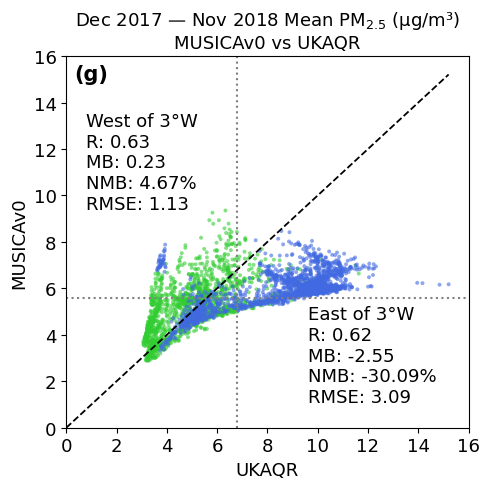

In [ ]:
# Summer


# var_name = "O3"
var_name = "PM25"

# MUSICA fv0.1
data_dir_musica = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01"
files_musica = (
    sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc"))
    + sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc"))
)

# MetOffice
# O3
# met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg"

# PM25
met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg"

gdf = gpd.read_file(met_gpkg)
gdf["stdTime"] = pd.to_datetime(gdf["stdTime"])

# start = pd.Timestamp("2017-12-01", tz="UTC")
# end   = pd.Timestamp("2018-12-01", tz="UTC")

# # djf. e a
# start = pd.Timestamp("2017-12-01", tz="UTC")
# end   = pd.Timestamp("2018-03-01", tz="UTC")

# # mam. f b
# start = pd.Timestamp("2017-03-01", tz="UTC")
# end   = pd.Timestamp("2018-06-01", tz="UTC")

# # # jja. g c
start = pd.Timestamp("2017-06-01", tz="UTC")
end   = pd.Timestamp("2018-09-01", tz="UTC")

# son. h d
# start = pd.Timestamp("2017-09-01", tz="UTC")
# end   = pd.Timestamp("2018-12-01", tz="UTC")

mask_time = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask_time].copy()

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)
gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds  # minx,miny,maxx,maxy
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()
pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lon_centers = pivot.columns.values.astype(float)
lat_centers = pivot.index.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))
lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

factor_met = 1.0
data2d_met = pivot.values
data2d_met_ppbv = data2d_met * factor_met

ne_admin1 = gpd.read_file(
    "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
)

if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL", "IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]
uk_ie_union = ne_uk_ie.union_all()

points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)
inside = points.within(uk_ie_union).values
mask_land = inside.reshape(data2d_met_ppbv.shape)

data2d_met_masked = np.where(mask_land, data2d_met_ppbv, np.nan)

ds_mus = xr.open_mfdataset(files_musica, combine="by_coords")

lons_raw = ds_mus["lon"]
lons_deg = xr.where(lons_raw > 180, lons_raw - 360, lons_raw)
ds_mus = ds_mus.assign_coords(lon=lons_deg)
ds_mus = ds_mus.sortby("lon")
factor_mus = 1e9
var3d = ds_mus[var_name] * factor_mus
var_sfc = var3d.isel(lev=-1)   
var_mean = var_sfc.mean(dim="time")

var_on_met = var_mean.interp(
    lat=lat_centers,
    lon=lon_centers
)

data2d_mus = var_on_met.values
data2d_mus_masked = np.where(mask_land, data2d_mus, np.nan)

diff = data2d_mus_masked - data2d_met_masked
absmax = np.nanmax(np.abs(diff))

cbar_obj = Cbar("myct_cont")
cmap_main = cbar_obj.cmap
cmap_diff = plt.get_cmap("RdBu_r")

# MUSICA vs UKAQR

x = data2d_met_masked.ravel()  
y = data2d_mus_masked.ravel()

mask_valid = (~np.isnan(x)) & (~np.isnan(y))
xv = x[mask_valid]
yv = y[mask_valid]

lonv = lonc2d.ravel()[mask_valid]

threshold = -3.0
mask_west = lonv < threshold     # West of 3°W
mask_east = lonv >= threshold    # East of 3°W

# PM25
xmin = 0
xmax = max(xv.max(), yv.max())   # PM2.5

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

# PM25
ax.scatter(
    xv[mask_west], yv[mask_west],
    s=8, alpha=0.6, edgecolor="none",
    color="limegreen",
    label="West of 3°W"
)

ax.scatter(
    xv[mask_east], yv[mask_east],
    s=8, alpha=0.6, edgecolor="none",
    color="royalblue",
    label="East of 3°W"
)

ax.set_xlim([xmin, xmax])
ax.set_ylim([xmin, xmax])

# PM25
ax.set_xticks(np.arange(xmin, xmax + 1, 2))
ax.set_yticks(np.arange(xmin, xmax + 1, 2))

xx = np.linspace(xmin, xmax, 200)
ax.plot(xx, xx, ls="--", lw=1.3, color="black", label="1:1")

mean_x = np.mean(xv)
mean_y = np.mean(yv)

ax.axvline(mean_x, ls=":", lw=1.5, color="grey")
ax.axhline(mean_y, ls=":", lw=1.5, color="grey")

ax.tick_params(axis="both", labelsize=13)
ax.set_xlabel("UKAQR", fontsize=13)
ax.set_ylabel("MUSICAv0", fontsize=13)

ax.set_title(
    "Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³)\nMUSICAv0 vs UKAQR",
    fontsize=13
)

def calc_stats(x_sub, y_sub):
    mb = np.mean(y_sub - x_sub)
    rmse = np.sqrt(np.mean((y_sub - x_sub) ** 2))
    corr = np.corrcoef(x_sub, y_sub)[0, 1] if len(x_sub) > 1 else np.nan
    nmb = np.sum(y_sub - x_sub) / np.sum(x_sub) * 100.0
    return corr, mb, nmb, rmse

# West / East
x_w, y_w = xv[mask_west], yv[mask_west]
x_e, y_e = xv[mask_east], yv[mask_east]

corr_w, mb_w, nmb_w, rmse_w = calc_stats(x_w, y_w)
corr_e, mb_e, nmb_e, rmse_e = calc_stats(x_e, y_e)

text_w = (
    "West of 3°W\n"
    f"R: {corr_w:.2f}\n"
    f"MB: {mb_w:.2f}\n"
    f"NMB: {nmb_w:.2f}%\n"
    f"RMSE: {rmse_w:.2f}"
)

text_e = (
    "East of 3°W\n"
    f"R: {corr_e:.2f}\n"
    f"MB: {mb_e:.2f}\n"
    f"NMB: {nmb_e:.2f}%\n"
    f"RMSE: {rmse_e:.2f}"
)

ax.text(
    0.05, 0.85, text_w,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

ax.text(
    0.60, 0.33, text_e,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

corr_all, mb_all, nmb_all, rmse_all = calc_stats(xv, yv)

# PM25
text_all = (
    "All UK\n"
    f"R: {corr_all:.2f}\n"
    f"MB: {mb_all:.2f}\n"
    f"NMB: {nmb_all:.2f}%\n"
    f"RMSE: {rmse_all:.2f}"
)

# ax.text(
#     0.43, 0.98, text_all,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     fontsize=13,
#     color="k"
# )

ax.text(
    0.02, 0.98, "(g)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15, fontweight="bold"
)

plt.tight_layout()

/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


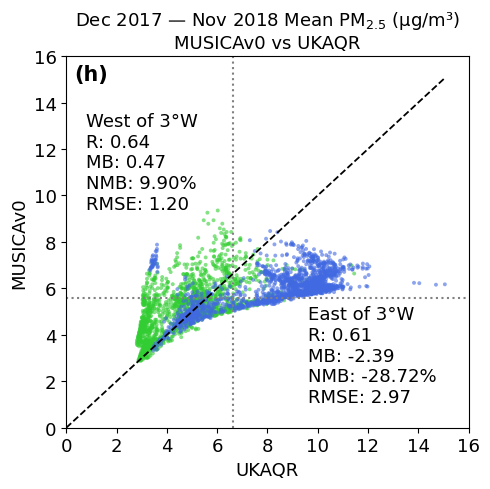

In [ ]:
# Autumn


# var_name = "O3"
var_name = "PM25"

# MUSICA fv0.1
data_dir_musica = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01"
files_musica = (
    sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc"))
    + sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc"))
)

# MetOffice
# O3
# met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg"

# PM25
met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg"

gdf = gpd.read_file(met_gpkg)
gdf["stdTime"] = pd.to_datetime(gdf["stdTime"])

# start = pd.Timestamp("2017-12-01", tz="UTC")
# end   = pd.Timestamp("2018-12-01", tz="UTC")

# # djf. e a
# start = pd.Timestamp("2017-12-01", tz="UTC")
# end   = pd.Timestamp("2018-03-01", tz="UTC")

# # mam. f b
# start = pd.Timestamp("2017-03-01", tz="UTC")
# end   = pd.Timestamp("2018-06-01", tz="UTC")

# # # jja. g c
# start = pd.Timestamp("2017-06-01", tz="UTC")
# end   = pd.Timestamp("2018-09-01", tz="UTC")

# son. h d
start = pd.Timestamp("2017-09-01", tz="UTC")
end   = pd.Timestamp("2018-12-01", tz="UTC")

mask_time = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask_time].copy()

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)
gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds  # minx,miny,maxx,maxy
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()
pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lon_centers = pivot.columns.values.astype(float)
lat_centers = pivot.index.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))
lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

factor_met = 1.0
data2d_met = pivot.values
data2d_met_ppbv = data2d_met * factor_met
ne_admin1 = gpd.read_file(
    "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
)

if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL", "IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]
uk_ie_union = ne_uk_ie.union_all()

points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)
inside = points.within(uk_ie_union).values
mask_land = inside.reshape(data2d_met_ppbv.shape)
data2d_met_masked = np.where(mask_land, data2d_met_ppbv, np.nan)
ds_mus = xr.open_mfdataset(files_musica, combine="by_coords")

lons_raw = ds_mus["lon"]
lons_deg = xr.where(lons_raw > 180, lons_raw - 360, lons_raw)
ds_mus = ds_mus.assign_coords(lon=lons_deg)
ds_mus = ds_mus.sortby("lon")
factor_mus = 1e9
var3d = ds_mus[var_name] * factor_mus
var_sfc = var3d.isel(lev=-1)   
var_mean = var_sfc.mean(dim="time")

var_on_met = var_mean.interp(
    lat=lat_centers,
    lon=lon_centers
)

data2d_mus = var_on_met.values
data2d_mus_masked = np.where(mask_land, data2d_mus, np.nan)

diff = data2d_mus_masked - data2d_met_masked
absmax = np.nanmax(np.abs(diff))

cbar_obj = Cbar("myct_cont")
cmap_main = cbar_obj.cmap
cmap_diff = plt.get_cmap("RdBu_r")

# MUSICA vs UKAQR

x = data2d_met_masked.ravel()  
y = data2d_mus_masked.ravel()

mask_valid = (~np.isnan(x)) & (~np.isnan(y))
xv = x[mask_valid]
yv = y[mask_valid]

lonv = lonc2d.ravel()[mask_valid]

threshold = -3.0
mask_west = lonv < threshold     # West of 3°W
mask_east = lonv >= threshold    # East of 3°W

# PM25
xmin = 0
xmax = max(xv.max(), yv.max())   # PM2.5

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

# PM25
ax.scatter(
    xv[mask_west], yv[mask_west],
    s=8, alpha=0.6, edgecolor="none",
    color="limegreen",
    label="West of 3°W"
)

ax.scatter(
    xv[mask_east], yv[mask_east],
    s=8, alpha=0.6, edgecolor="none",
    color="royalblue",
    label="East of 3°W"
)

ax.set_xlim([xmin, xmax])
ax.set_ylim([xmin, xmax])

# PM25
ax.set_xticks(np.arange(xmin, xmax + 1, 2))
ax.set_yticks(np.arange(xmin, xmax + 1, 2))

xx = np.linspace(xmin, xmax, 200)
ax.plot(xx, xx, ls="--", lw=1.3, color="black", label="1:1")

mean_x = np.mean(xv)
mean_y = np.mean(yv)

ax.axvline(mean_x, ls=":", lw=1.5, color="grey")
ax.axhline(mean_y, ls=":", lw=1.5, color="grey")

ax.tick_params(axis="both", labelsize=13)
ax.set_xlabel("UKAQR", fontsize=13)
ax.set_ylabel("MUSICAv0", fontsize=13)

ax.set_title(
    "Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³)\nMUSICAv0 vs UKAQR",
    fontsize=13
)

def calc_stats(x_sub, y_sub):
    mb = np.mean(y_sub - x_sub)
    rmse = np.sqrt(np.mean((y_sub - x_sub) ** 2))
    corr = np.corrcoef(x_sub, y_sub)[0, 1] if len(x_sub) > 1 else np.nan
    nmb = np.sum(y_sub - x_sub) / np.sum(x_sub) * 100.0
    return corr, mb, nmb, rmse

# West / East
x_w, y_w = xv[mask_west], yv[mask_west]
x_e, y_e = xv[mask_east], yv[mask_east]

corr_w, mb_w, nmb_w, rmse_w = calc_stats(x_w, y_w)
corr_e, mb_e, nmb_e, rmse_e = calc_stats(x_e, y_e)

text_w = (
    "West of 3°W\n"
    f"R: {corr_w:.2f}\n"
    f"MB: {mb_w:.2f}\n"
    f"NMB: {nmb_w:.2f}%\n"
    f"RMSE: {rmse_w:.2f}"
)

text_e = (
    "East of 3°W\n"
    f"R: {corr_e:.2f}\n"
    f"MB: {mb_e:.2f}\n"
    f"NMB: {nmb_e:.2f}%\n"
    f"RMSE: {rmse_e:.2f}"
)

ax.text(
    0.05, 0.85, text_w,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

ax.text(
    0.60, 0.33, text_e,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    color="k"
)

corr_all, mb_all, nmb_all, rmse_all = calc_stats(xv, yv)

# PM25
text_all = (
    "All UK\n"
    f"R: {corr_all:.2f}\n"
    f"MB: {mb_all:.2f}\n"
    f"NMB: {nmb_all:.2f}%\n"
    f"RMSE: {rmse_all:.2f}"
)

# ax.text(
#     0.43, 0.98, text_all,
#     transform=ax.transAxes,
#     ha="left", va="top",
#     fontsize=13,
#     color="k"
# )

ax.text(
    0.02, 0.98, "(h)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15, fontweight="bold"
)

plt.tight_layout()